In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


In [2]:
from pathlib import Path
from collections import Counter, defaultdict
from pprint import pprint

DATA_ROOT = Path("Data")  # change if needed (case-sensitive)

if (DATA_ROOT / "train").exists():
    SPLITS = {
        "train": DATA_ROOT / "train",
        **({"val":  DATA_ROOT / "val"}  if (DATA_ROOT / "val").exists()  else {}),
        **({"test": DATA_ROOT / "test"} if (DATA_ROOT / "test").exists() else {}),
    }
else:
    # Single folder that directly contains class subfolders
    SPLITS = {"all": DATA_ROOT}

print("Found splits:")
for k, v in SPLITS.items():
    print(f"  {k}: {v}")


Found splits:
  all: Data


In [3]:
from torchvision import datasets

all_info = {}
for split, root in SPLITS.items():
    ds = datasets.ImageFolder(root=str(root))
    class_names = ds.classes                        # e.g., ['angry','happy','neutral','sad']
    counts_idx = Counter(ds.targets)                # targets are class indices
    counts = {class_names[i]: counts_idx.get(i, 0) for i in range(len(class_names))}
    total = len(ds)

    all_info[split] = {
        "num_classes": len(class_names),
        "classes": class_names,
        "per_class_counts": counts,
        "total_images": total,
        "class_to_idx": ds.class_to_idx,
    }

print("== Dataset summary (quick) ==")
for split, info in all_info.items():
    print(f"\n[{split}]")
    print("  num_classes:", info["num_classes"])
    print("  total_images:", info["total_images"])
    print("  classes:", info["classes"])
    print("  per_class_counts:")
    for c, n in sorted(info["per_class_counts"].items(), key=lambda x: (-x[1], x[0])):
        print(f"    {c:>10}: {n}")


== Dataset summary (quick) ==

[all]
  num_classes: 5
  total_images: 59099
  classes: ['Angry', 'Fear', 'Happy', 'Sad', 'Surprise']
  per_class_counts:
         Happy: 18439
           Sad: 12553
         Angry: 10148
          Fear: 9732
      Surprise: 8227


In [4]:
from pathlib import Path

root = Path("Data")  # your current root with class folders inside
old = root / "Suprise"
new = root / "Surprise"
if old.exists() and not new.exists():
    old.rename(new)
    print("Renamed 'Suprise' -> 'Surprise'")
else:
    print("Nothing to rename (already clean or folder missing).")


Nothing to rename (already clean or folder missing).


In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch

ROOT = "Data"  # contains class subfolders directly
IMG_SIZE = 224

# Transforms
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# A base dataset to get file order + labels
base = datasets.ImageFolder(ROOT)  # no transform; we only need .targets and .samples
y = np.array(base.targets)
num_classes = len(base.classes)
print("Classes:", base.classes)

# 80/10/10 split, stratified
idx_all = np.arange(len(y))
idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    idx_all, y, test_size=0.20, random_state=42, stratify=y
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print(f"Split sizes -> train: {len(idx_train)}, val: {len(idx_val)}, test: {len(idx_test)}")

# Three datasets with SAME file ordering, different transforms
ds_train = datasets.ImageFolder(ROOT, transform=train_tf)
ds_val   = datasets.ImageFolder(ROOT, transform=eval_tf)
ds_test  = datasets.ImageFolder(ROOT, transform=eval_tf)

# Subset views using our indices
train_set = Subset(ds_train, idx_train)
val_set   = Subset(ds_val,   idx_val)
test_set  = Subset(ds_test,  idx_test)

def count_per_class(subset, all_classes):
    # subset.dataset is ImageFolder; subset.indices points to base order
    # We can use base.targets for fast counting
    cls_counts = {c: 0 for c in all_classes}
    for i in subset.indices:
        cidx = base.targets[i]
        cls_counts[all_classes[cidx]] += 1
    return cls_counts

print("Train per-class:", count_per_class(train_set, base.classes))
print("Val   per-class:", count_per_class(val_set,   base.classes))
print("Test  per-class:", count_per_class(test_set,  base.classes))


Classes: ['Angry', 'Fear', 'Happy', 'Sad', 'Surprise']
Split sizes -> train: 47279, val: 5910, test: 5910
Train per-class: {'Angry': 8118, 'Fear': 7786, 'Happy': 14751, 'Sad': 10042, 'Surprise': 6582}
Val   per-class: {'Angry': 1015, 'Fear': 973, 'Happy': 1844, 'Sad': 1255, 'Surprise': 823}
Test  per-class: {'Angry': 1015, 'Fear': 973, 'Happy': 1844, 'Sad': 1256, 'Surprise': 822}


In [6]:
# === Cell 1: imports & dataset root ===
from pathlib import Path
from torchvision import datasets
from PIL import Image, UnidentifiedImageError
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("Data")  # adjust if needed
assert DATA_DIR.exists(), f"Not found: {DATA_DIR}"


In [7]:
# === Cell 2: build ImageFolder over a single folder with class subfolders ===
ds = datasets.ImageFolder(root=str(DATA_DIR))
idx_to_class = {v: k for k, v in ds.class_to_idx.items()}
print("Classes:", [idx_to_class[i] for i in range(len(idx_to_class))])
print("Total images:", len(ds))


Classes: ['Angry', 'Fear', 'Happy', 'Sad', 'Surprise']
Total images: 59099


In [8]:
# === Cell 3: scan images → dataframe with path, class, width/height, mode, bytes, ok ===
rows = []
corrupt = []

for path, cls_idx in ds.samples:   # (filepath, class_index)
    cls = idx_to_class[cls_idx]
    p = Path(path)
    size_bytes = p.stat().st_size if p.exists() else None
    w = h = None
    mode = None
    ok = True
    try:
        with Image.open(p) as im:
            w, h = im.size
            mode = im.mode
    except (UnidentifiedImageError, OSError) as e:
        ok = False
        corrupt.append((cls, str(p), repr(e)))
    rows.append({
        "class": cls,
        "path": str(p),
        "width": w,
        "height": h,
        "mode": mode,
        "bytes": size_bytes,
        "ok": ok,
    })

df = pd.DataFrame(rows)
print("Scanned:", len(df), "files  |  Corrupt/unreadable:", (~df["ok"]).sum())
# === Cell 4: quick summaries ===
print("Per-class counts:\n")
print(df[df["ok"]]["class"].value_counts())

print("\nImage size stats (ok only):\n")
print(df[df["ok"]][["width","height"]].describe())

print("\nImage modes:\n")
print(df[df["ok"]]["mode"].value_counts())

# Top 10 most common sizes
common_sizes = (df[df["ok"]]
                .assign(size=lambda x: list(zip(x["width"], x["height"])))
                .value_counts("size")
                .head(10))
print("\nTop 10 sizes:\n")
print(common_sizes)
df.head(3)



Scanned: 59099 files  |  Corrupt/unreadable: 0
Per-class counts:

class
Happy       18439
Sad         12553
Angry       10148
Fear         9732
Surprise     8227
Name: count, dtype: int64

Image size stats (ok only):

              width        height
count  59099.000000  59099.000000
mean      80.886056     80.393611
std      336.623670    335.071391
min       48.000000     48.000000
25%       48.000000     48.000000
50%       48.000000     48.000000
75%       48.000000     48.000000
max     8957.000000   8660.000000

Image modes:

mode
L       57758
RGB      1338
RGBA        3
Name: count, dtype: int64

Top 10 sizes:

size
(48, 48)        57756
(640, 640)        864
(4000, 6000)       23
(150, 100)         16
(6000, 4000)       16
(1600, 1067)       12
(150, 225)          7
(4480, 6720)        7
(6720, 4480)        7
(2000, 3000)        6
Name: count, dtype: int64


,class,path,width,height,mode,bytes,ok
0,Angry,Data/Angry/0.png,48,48,L,1688,True
1,Angry,Data/Angry/1.png,48,48,L,1908,True
2,Angry,Data/Angry/10.png,48,48,L,1865,True


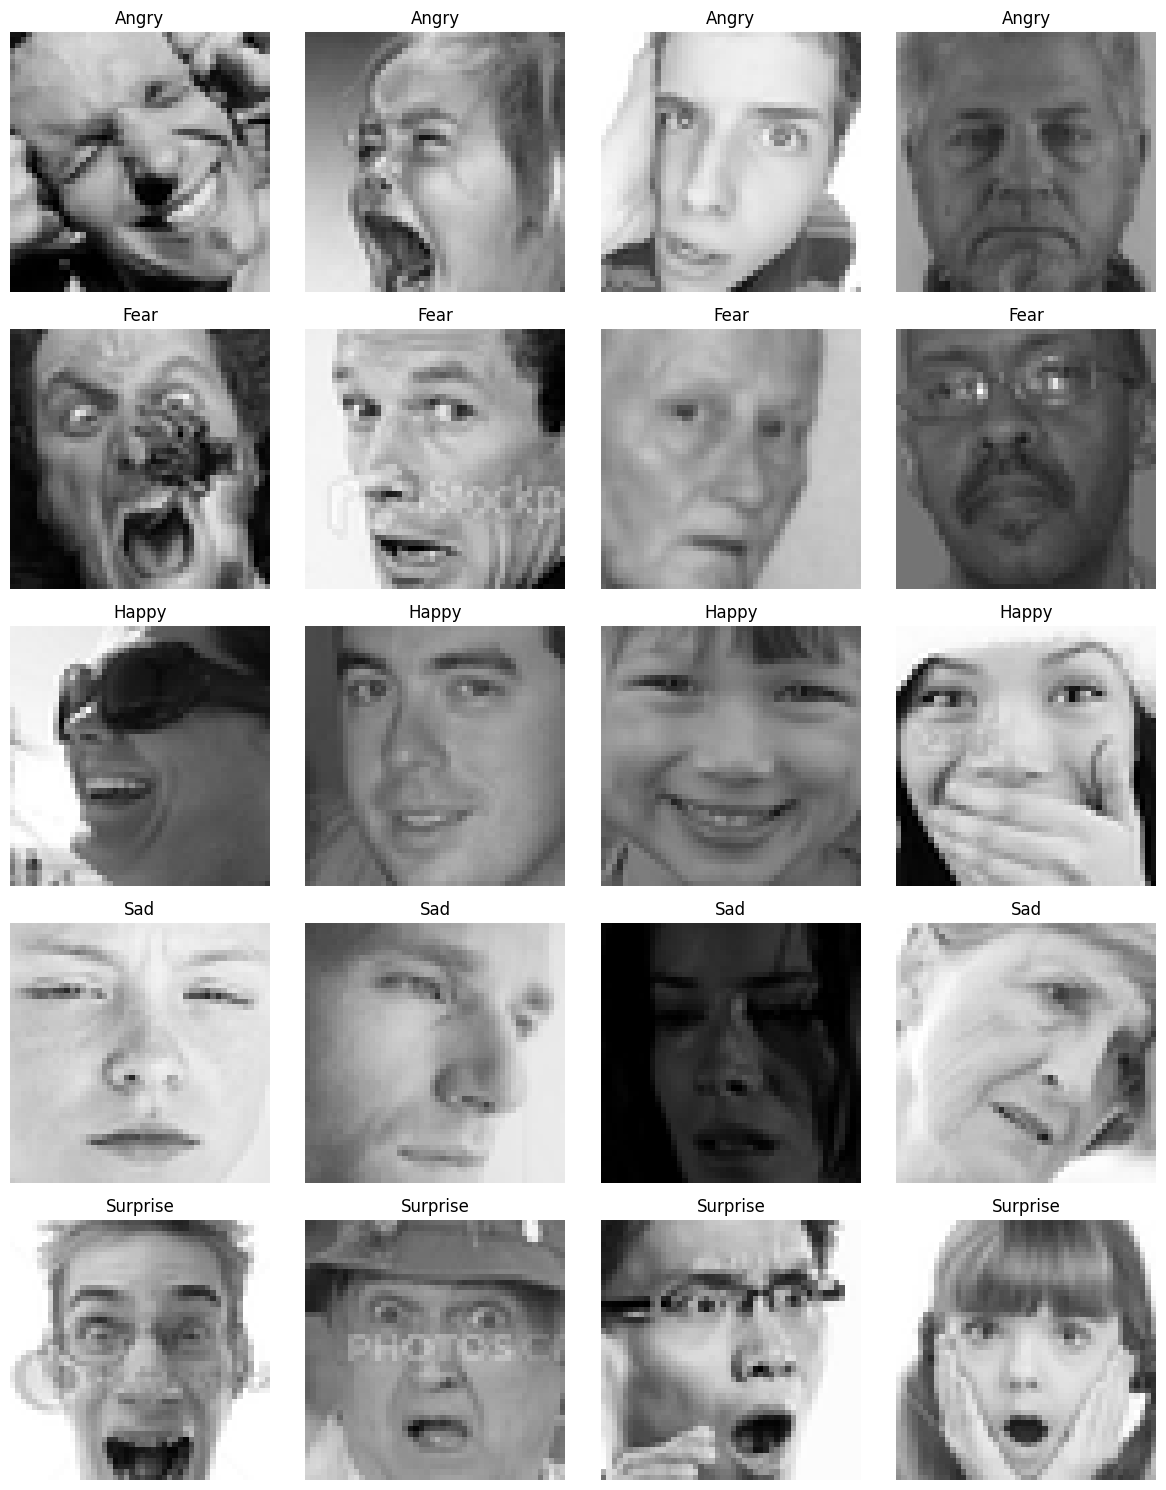

In [9]:
# === Cell 6: show a grid of example images per class ===
def show_examples(df, per_class=4, seed=0):
    rng = np.random.default_rng(seed)
    ok_df = df[df["ok"]]
    classes = sorted(ok_df["class"].unique())
    nrows, ncols = len(classes), per_class
    plt.figure(figsize=(ncols*3, nrows*3))
    i = 1
    for cls in classes:
        paths = ok_df.loc[ok_df["class"]==cls, "path"]
        k = min(per_class, len(paths))
        for p in paths.sample(k, random_state=seed):
            with Image.open(p).convert("RGB") as im:
                plt.subplot(nrows, ncols, i)
                plt.imshow(im)
                plt.axis("off")
                plt.title(cls)
                i += 1
    plt.tight_layout()
    plt.show()

show_examples(df, per_class=4, seed=42)


Class : Angry
Path  : Data/Angry/0.png
Size  : (np.int64(48), np.int64(48))
Mode  : L
Bytes : 1688
OK    : True


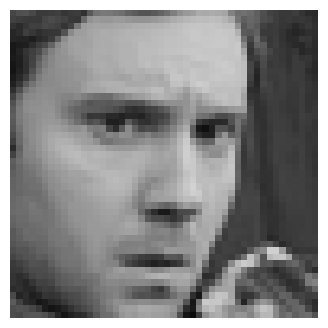

In [10]:
# === Cell 7: inspect one image by index or path (prints metadata + shows image) ===
def show_one(df, idx=None, path=None):
    if path is not None:
        row = df[df["path"]==str(path)].iloc[0]
    else:
        if idx is None:
            idx = np.random.randint(len(df))
        row = df.iloc[idx]
    print("Class :", row["class"])
    print("Path  :", row["path"])
    print("Size  :", (row["width"], row["height"]))
    print("Mode  :", row["mode"])
    print("Bytes :", row["bytes"])
    print("OK    :", row["ok"])
    if row["ok"]:
        with Image.open(row["path"]).convert("RGB") as im:
            plt.figure(figsize=(4,4))
            plt.imshow(im)
            plt.axis("off")
            plt.show()

# Examples:
show_one(df, idx=0)                # by index
# show_one(df, path="Data/Happy/xxx.jpg")  # or by path


In [11]:
import pandas as pd

# show full value_counts without "..."
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Image modes (full):")
print(df[df["ok"]]["mode"].value_counts().to_string())

print("\nTop 25 sizes:")
sizes = (
    df[df["ok"]]
    .assign(size=list(zip(df["width"], df["height"])))
    .value_counts("size")
    .head(25)
)
print(sizes.to_string())


Image modes (full):
mode
L       57758
RGB      1338
RGBA        3

Top 25 sizes:
size
(48, 48)        57756
(640, 640)        864
(4000, 6000)       23
(150, 100)         16
(6000, 4000)       16
(1600, 1067)       12
(150, 225)          7
(4480, 6720)        7
(6720, 4480)        7
(2000, 3000)        6
(275, 183)          6
(3456, 5184)        5
(5184, 3456)        5
(3648, 5472)        5
(5760, 3840)        5
(100, 100)          5
(1600, 2400)        5
(3840, 5760)        5
(1920, 1080)        5
(2333, 3500)        5
(3840, 2160)        5
(8192, 5461)        4
(3888, 5184)        4
(4000, 5334)        3
(5616, 3744)        3


In [28]:
# ==== Imports & device ====
import random
from collections import defaultdict, Counter
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
DATA_DIR = Path("Data")
# ==== Build a stratified train/val split from your single folder ====
# (keeps class balance)
VAL_RATIO = 0.22
SEED = 42
random.seed(SEED)

base_ds = datasets.ImageFolder(root=str(DATA_DIR))  # no transform here
num_classes = len(base_ds.classes)
print("Classes:", base_ds.classes)

cls_to_indices = defaultdict(list)
for i, (_, cls_idx) in enumerate(base_ds.samples):
    cls_to_indices[cls_idx].append(i)

train_idx, val_idx = [], []
for cls_idx, idxs in cls_to_indices.items():
    random.shuffle(idxs)
    n_val = max(1, int(len(idxs) * VAL_RATIO))
    val_idx += idxs[:n_val]
    train_idx += idxs[n_val:]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)}")


Device: cuda
Classes: ['Angry', 'Fear', 'Happy', 'Sad', 'Surprise']
Train: 46100 | Val: 12999


In [37]:
# ==== Datasets + subsets ====
train_full = datasets.ImageFolder(root=str(DATA_DIR), transform=train_tf)
val_full   = datasets.ImageFolder(root=str(DATA_DIR), transform=eval_tf)

train_ds = Subset(train_full, train_idx)
val_ds   = Subset(val_full,   val_idx)

# compute class weights from the TRAIN subset for imbalance handling
train_targets = [train_full.samples[i][1] for i in train_idx]
counts = Counter(train_targets)
class_weights = torch.tensor(
    [1.0 / max(1, counts[c]) for c in range(num_classes)],
    dtype=torch.float
)
sample_weights = [class_weights[t].item() for t in train_targets]

sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

print("Class counts (train):", {train_full.classes[c]: counts[c] for c in range(num_classes)})


Class counts (train): {'Angry': 7916, 'Fear': 7591, 'Happy': 14383, 'Sad': 9792, 'Surprise': 6418}


MobileNetV3-Large


In [46]:
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /home/nosrati/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth
100%|██████████| 21.1M/21.1M [00:02<00:00, 10.3MB/s]


ResNet18

In [39]:
# ==== Model: ResNet18 transfer learning ====
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Loss (use class weights) + Optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [47]:
# ==== Train / Eval loops ====
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum = correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(1)
        total += y.size(0)
        correct += (pred == y).sum().item()
    return loss_sum / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum = correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(1)
        total += y.size(0)
        correct += (pred == y).sum().item()
    return loss_sum / total, correct / total


In [41]:
# --- Cell: realtime training with tqdm + live matplotlib plots ---
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# (re)define train/eval to show per-batch progress
def train_one_epoch_rt(model, loader, criterion, optimizer, device, epoch_idx=None):
    model.train()
    loss_sum = correct = total = 0
    pbar = tqdm(loader, desc=f"Train{'' if epoch_idx is None else f' [{epoch_idx}]'}", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # running stats
        batch_loss = loss.item()
        loss_sum += batch_loss * x.size(0)
        pred = logits.argmax(1)
        total += y.size(0)
        correct += (pred == y).sum().item()
        pbar.set_postfix(loss=f"{batch_loss:.4f}", acc=f"{(correct/total):.4f}")

    return loss_sum / total, correct / total

@torch.no_grad()
def evaluate_rt(model, loader, criterion, device, epoch_idx=None):
    model.eval()
    loss_sum = correct = total = 0
    pbar = tqdm(loader, desc=f"Valid{'' if epoch_idx is None else f' [{epoch_idx}]'}", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        loss_sum += loss.item() * x.size(0)
        pred = logits.argmax(1)
        total += y.size(0)
        correct += (pred == y).sum().item()

        pbar.set_postfix(loss=f"{(loss_sum/total):.4f}", acc=f"{(correct/total):.4f}")

    return loss_sum / total, correct / total

# live plot helper
def plot_history(history):
    clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(history["train_loss"], label="train")
    ax[0].plot(history["val_loss"],   label="val")
    ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(history["train_acc"], label="train")
    ax[1].plot(history["val_acc"],   label="val")
    ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout()
    display(fig)
    plt.close(fig)


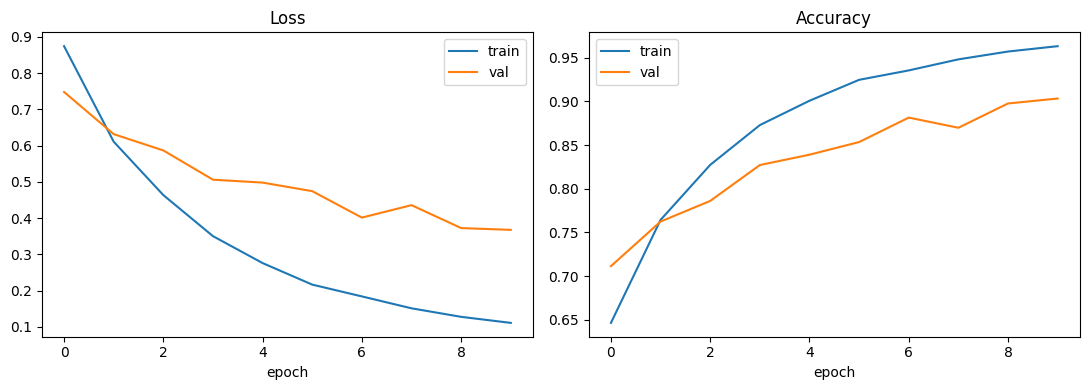

Epoch 10 | train loss 0.1107 acc 0.9631 | val loss 0.3674 acc 0.9032
  🔥 New best model!
Best val acc: 0.903223324871144


In [42]:
# --- Cell: run training with realtime output ---
EPOCHS = 10
best_val_acc = 0.0
best_state = None

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch_rt(model, train_loader, criterion, optimizer, device, epoch_idx=epoch)
    va_loss, va_acc = evaluate_rt(model, val_loader, criterion, device, epoch_idx=epoch)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    # live chart update each epoch
    plot_history(history)

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print("  🔥 New best model!")

if best_state is not None:
    model.load_state_dict(best_state)
print("Best val acc:", best_val_acc)
from torch.utils.tensorboard import SummaryWriter
tb = SummaryWriter(log_dir="runs/emotion_resnet18")

              precision    recall  f1-score   support

       Angry     0.8418    0.8866    0.8636      2232
        Fear     0.8271    0.8178    0.8225      2141
       Happy     0.9749    0.9386    0.9564      4056
         Sad     0.8483    0.8464    0.8474      2761
    Surprise     0.9193    0.9508    0.9348      1809

    accuracy                         0.8919     12999
   macro avg     0.8823    0.8881    0.8849     12999
weighted avg     0.8931    0.8919    0.8922     12999



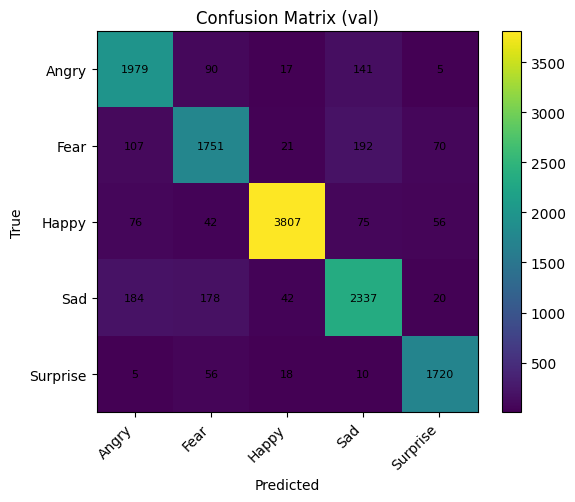

In [ ]:
# Confusion matrix + classification report for validation set
import torch, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)
        pred = logits.argmax(1).cpu().numpy()
        all_preds.append(pred)
        all_labels.append(y.numpy())
all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

idx_to_class = {v:k for k,v in train_full.class_to_idx.items()}
labels_sorted = list(range(len(idx_to_class)))
target_names = [idx_to_class[i] for i in labels_sorted]

print(classification_report(all_labels, all_preds, labels=labels_sorted, target_names=target_names, digits=4))

cm = confusion_matrix(all_labels, all_preds, labels=labels_sorted)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, interpolation="nearest")
ax.set_title("Confusion Matrix (val)")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_xticks(range(len(target_names))); ax.set_yticks(range(len(target_names)))
ax.set_xticklabels(target_names, rotation=45, ha="right"); ax.set_yticklabels(target_names)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)
fig.colorbar(im)
plt.tight_layout(); plt.show()


Wrong predictions: 1259


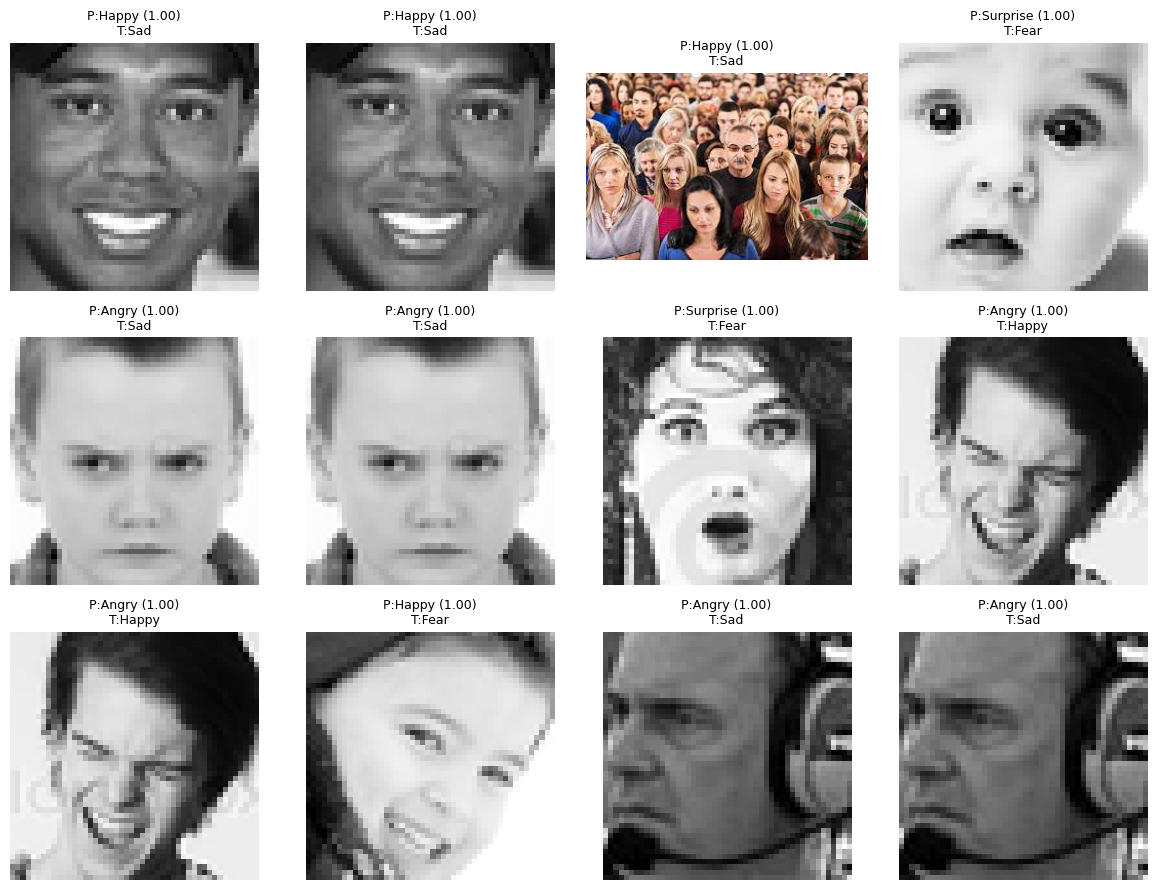

In [43]:
import torch.nn.functional as F
import math
from PIL import Image

# collect (prob, true, pred, path) for wrong ones
wrong = []
model.eval()
with torch.no_grad():
    for i in val_ds.indices:                  # iterate original indices of val subset
        x, y_true = val_full[i]               # transformed sample
        logits = model(x.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        y_pred = probs.argmax()
        if y_pred != y_true:
            wrong.append((probs[y_pred], y_true, y_pred, val_full.samples[i][0]))

# sort by confidence descending (most confident but wrong)
wrong.sort(key=lambda t: -t[0])
print("Wrong predictions:", len(wrong))

# show top-N wrong
N = 12
cols = 4
rows = math.ceil(min(N, len(wrong)) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
axes = np.array(axes).reshape(rows, cols)

for ax in axes.flat: ax.axis("off")
for ax, (p, y_true, y_pred, path) in zip(axes.flat, wrong[:N]):
    img = Image.open(path).convert("RGB")
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"P:{idx_to_class[y_pred]} ({p:.2f})\nT:{idx_to_class[y_true]}", fontsize=9)
plt.tight_layout(); plt.show()


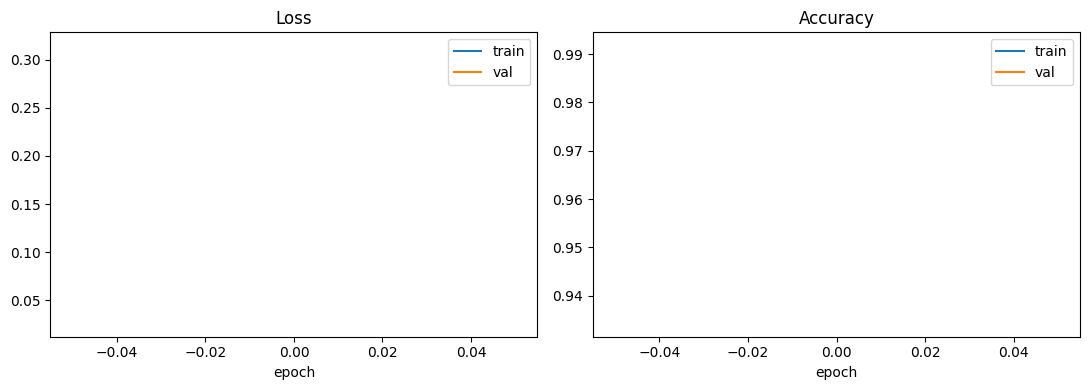

[FT] Epoch 08 | train 0.0266/0.9916 | val 0.3140/0.9344
  🔥 New best (fine-tune)
Best val acc after fine-tune: 0.9343795676590507


In [44]:
# Unfreeze everything
for p in model.parameters():
    p.requires_grad = True

# Lower LR for fine-tuning + scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2, verbose=True)

FINE_EPOCHS = 8
best_val_acc_ft = best_val_acc
best_state_ft = {k: v.cpu().clone() for k,v in model.state_dict().items()}

for epoch in range(1, FINE_EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch_rt(model, train_loader, criterion, optimizer, device, epoch_idx=f"FT{epoch}")
    va_loss, va_acc = evaluate_rt(model, val_loader, criterion, device, epoch_idx=f"FT{epoch}")
    plot_history({
        "train_loss":[tr_loss], "val_loss":[va_loss], "train_acc":[tr_acc], "val_acc":[va_acc]
    })  # quick one-epoch plot; optional

    print(f"[FT] Epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f}")
    scheduler.step(va_acc)
    if va_acc > best_val_acc_ft:
        best_val_acc_ft = va_acc
        best_state_ft = {k: v.cpu().clone() for k,v in model.state_dict().items()}
        print("  🔥 New best (fine-tune)")

model.load_state_dict(best_state_ft)
print("Best val acc after fine-tune:", best_val_acc_ft)


In [45]:
# Metrics on the validation set
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_fscore_support

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = model(x)
        pred = logits.argmax(1).cpu().numpy()
        y_pred.append(pred)
        y_true.append(y.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

num_classes = len(train_full.class_to_idx)
idx_to_class = {v: k for k, v in train_full.class_to_idx.items()}

# Overall scores
acc = accuracy_score(y_true, y_pred)
prec_macro  = precision_score(y_true, y_pred, average="macro",   zero_division=0)
recall_macro= recall_score(   y_true, y_pred, average="macro",   zero_division=0)
prec_weight = precision_score(y_true, y_pred, average="weighted",zero_division=0)
recall_weight=recall_score(   y_true, y_pred, average="weighted",zero_division=0)
prec_micro  = precision_score(y_true, y_pred, average="micro",   zero_division=0)
recall_micro= recall_score(   y_true, y_pred, average="micro",   zero_division=0)

print(f"Accuracy                : {acc:.4f}")
print(f"Precision (macro)       : {prec_macro:.4f}")
print(f"Recall    (macro)       : {recall_macro:.4f}")
print(f"Precision (weighted)    : {prec_weight:.4f}")
print(f"Recall    (weighted)    : {recall_weight:.4f}")
print(f"Precision (micro)       : {prec_micro:.4f}")
print(f"Recall    (micro)       : {recall_micro:.4f}")

# Per-class metrics
prec_c, rec_c, f1_c, supp_c = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(num_classes)), zero_division=0
)

print("\nPer-class metrics:")
for i in range(num_classes):
    cname = idx_to_class.get(i, str(i))
    print(f"{cname:>10} | P: {prec_c[i]:.4f}  R: {rec_c[i]:.4f}  F1: {f1_c[i]:.4f}  N: {supp_c[i]}")


Accuracy                : 0.9344
Precision (macro)       : 0.9283
Recall    (macro)       : 0.9301
Precision (weighted)    : 0.9346
Recall    (weighted)    : 0.9344
Precision (micro)       : 0.9344
Recall    (micro)       : 0.9344

Per-class metrics:
     Angry | P: 0.9054  R: 0.9220  F1: 0.9137  N: 2232
      Fear | P: 0.8925  R: 0.8767  F1: 0.8845  N: 2141
     Happy | P: 0.9837  R: 0.9697  F1: 0.9767  N: 4056
       Sad | P: 0.9059  R: 0.9171  F1: 0.9114  N: 2761
  Surprise | P: 0.9541  R: 0.9652  F1: 0.9596  N: 1809
